# LLM Benchmark Analysis
**Rohan Pant — MS Data Science, Rutgers University**

This notebook analyses results from two evaluation phases:
- **Phase 1**: 14 deterministic prompts × 9 capability categories across 4 local models
- **Phase 2**: RAG over a real document — 10 questions, 5 models (4 local + Groq cloud)

All local models run as Q4_K_M GGUFs via llama-cpp-python on Apple Silicon.

In [1]:
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
REPO   = Path('..').resolve()
EVAL   = REPO / 'eval'
RAG    = REPO / 'server' / 'data' / 'eval'

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':     'DejaVu Sans',
    'font.size':       11,
    'axes.titlesize':  13,
    'axes.titleweight':'bold',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'figure.dpi':      140,
    'savefig.dpi':     200,
    'savefig.bbox':    'tight',
})

# Consistent colour palette — one colour per model
MODEL_COLORS = {
    'Llama 3.1 8B':  '#4C72B0',
    'Qwen 2.5 7B':   '#DD8452',
    'Phi-3.5 Mini':  '#55A868',
    'Mistral 7B':    '#C44E52',
    'DeepSeek V3.2': '#8172B3',
    'Groq Llama3 70B': '#64B5CD',
}

print('Setup complete.')

Setup complete.


## 1. Load Phase 1 Data

In [2]:
# ── Load raw eval records ──────────────────────────────────────────────────
jsonl_files = sorted(EVAL.glob('results_phase1_*.jsonl'))
raw_records = []
for f in jsonl_files:
    for line in f.read_text().splitlines():
        line = line.strip()
        if line:
            raw_records.append(json.loads(line))

raw = pd.DataFrame(raw_records)

# ── Load scored results ────────────────────────────────────────────────────
score_files = sorted(EVAL.glob('scores_phase1_*.csv'))
scores = pd.read_csv(score_files[-1])   # most recent

# ── Clean model names for display ─────────────────────────────────────────
NAME_MAP = {
    'llama3.1-8b-instruct':      'Llama 3.1 8B',
    'qwen2.5-7b-instruct':       'Qwen 2.5 7B',
    'phi-3-mini-instruct':       'Phi-3.5 Mini',
    'mistral-7b-instruct':       'Mistral 7B',
    'deepseek-v3.2-7b-instruct': 'DeepSeek V3.2',
}
scores['model_label'] = scores['model'].map(NAME_MAP).fillna(scores['model'])
raw['model_label']    = raw['model'].map(NAME_MAP).fillna(raw['model'])

# ── Summary per model ─────────────────────────────────────────────────────
summary = (
    scores.groupby('model_label')
    .agg(
        accuracy       = ('score',      'mean'),
        avg_latency_ms = ('latency_ms', 'mean'),
        n_prompts      = ('score',      'count'),
    )
    .reset_index()
    .sort_values('accuracy', ascending=False)
)
summary['accuracy_pct'] = (summary['accuracy'] * 100).round(1)
summary['avg_latency_s'] = (summary['avg_latency_ms'] / 1000).round(2)

print(summary[['model_label','accuracy_pct','avg_latency_s','n_prompts']].to_string(index=False))

  model_label  accuracy_pct  avg_latency_s  n_prompts
  Qwen 2.5 7B          89.3           4.93         14
 Llama 3.1 8B          85.7           4.73         14
 Phi-3.5 Mini          71.4           9.32         14
   Mistral 7B          53.6          14.40         14
DeepSeek V3.2          46.4          38.47         14


## 2. Overall Accuracy & Latency — Side-by-Side

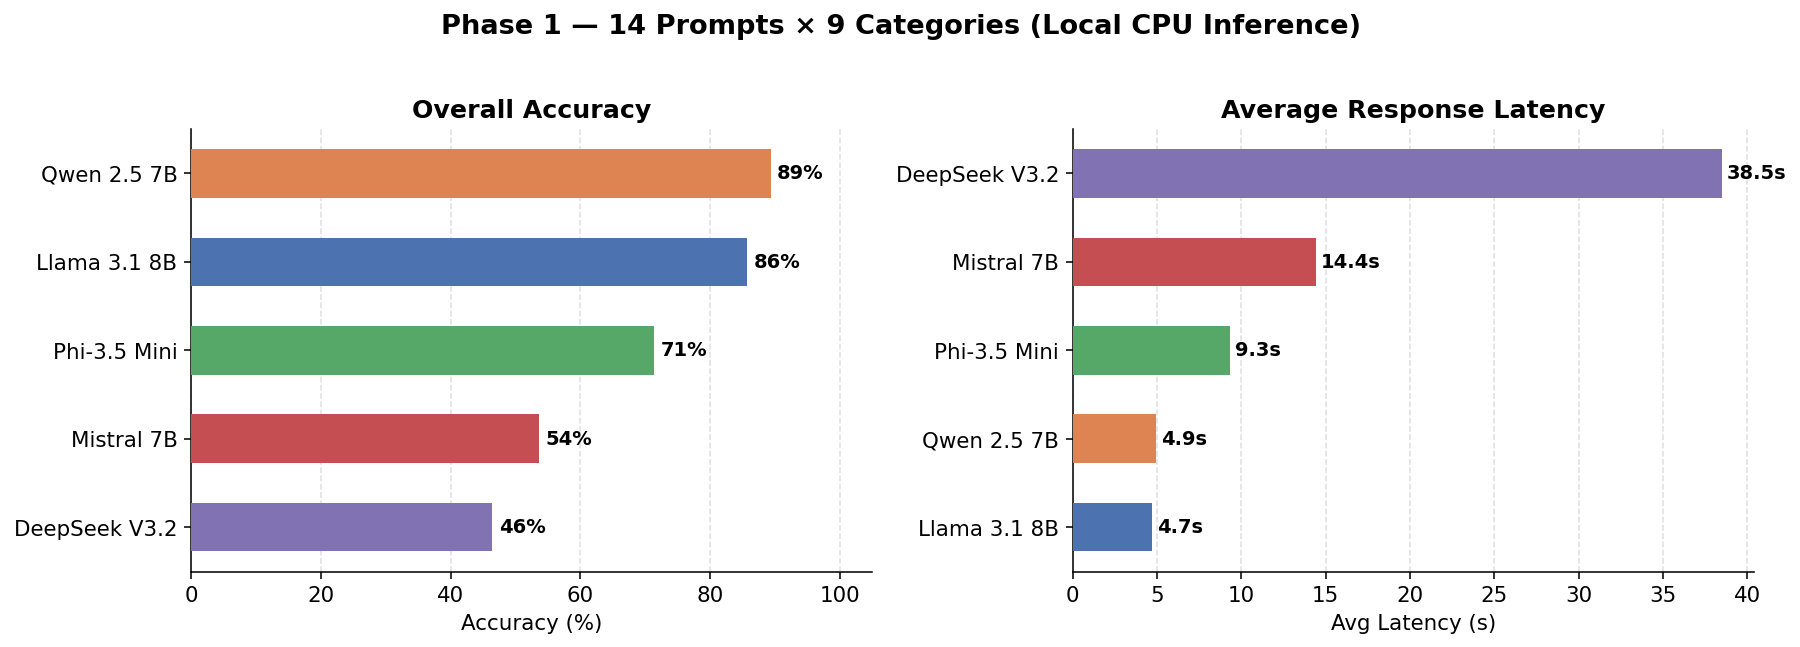

Saved → eval/fig1_accuracy_latency.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Phase 1 — 14 Prompts × 9 Categories (Local CPU Inference)', fontsize=14, fontweight='bold', y=1.02)

df = summary.sort_values('accuracy_pct', ascending=True)   # ascending for horizontal bars
colors = [MODEL_COLORS.get(m, '#888') for m in df['model_label']]

# ── Left: Accuracy ────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.barh(df['model_label'], df['accuracy_pct'], color=colors, height=0.55, zorder=3)
ax.set_xlabel('Accuracy (%)')
ax.set_title('Overall Accuracy')
ax.set_xlim(0, 105)
ax.xaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
for bar, val in zip(bars, df['accuracy_pct']):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}%', va='center', fontsize=10, fontweight='bold')

# ── Right: Latency ────────────────────────────────────────────────────────
df2 = summary.sort_values('avg_latency_s', ascending=True)
colors2 = [MODEL_COLORS.get(m, '#888') for m in df2['model_label']]
ax2 = axes[1]
bars2 = ax2.barh(df2['model_label'], df2['avg_latency_s'], color=colors2, height=0.55, zorder=3)
ax2.set_xlabel('Avg Latency (s)')
ax2.set_title('Average Response Latency')
ax2.xaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
for bar, val in zip(bars2, df2['avg_latency_s']):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}s', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(EVAL / 'fig1_accuracy_latency.png')
plt.show()
print('Saved → eval/fig1_accuracy_latency.png')

## 3. Accuracy vs Latency — The Trade-off Chart

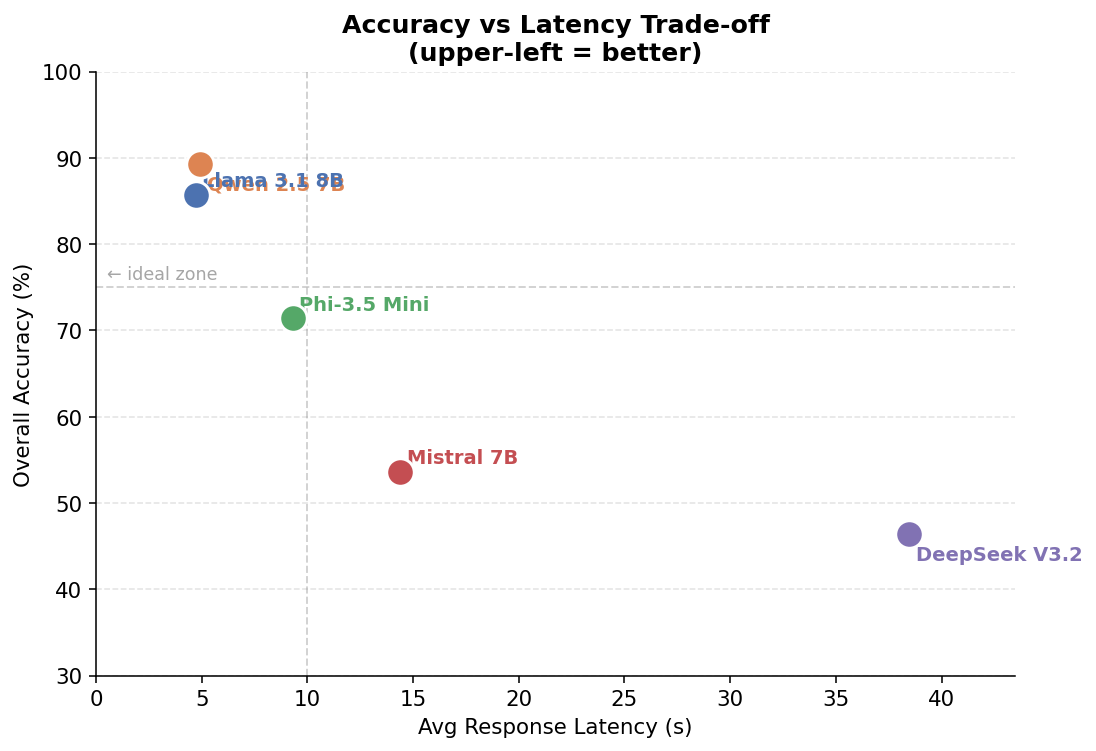

Saved → eval/fig2_tradeoff_scatter.png


In [4]:
fig, ax = plt.subplots(figsize=(8, 5.5))

for _, row in summary.iterrows():
    color = MODEL_COLORS.get(row['model_label'], '#888')
    ax.scatter(row['avg_latency_s'], row['accuracy_pct'],
               s=200, color=color, zorder=4, edgecolors='white', linewidths=1.5)
    # Label offset: nudge to avoid overlaps
    nudge = {'Llama 3.1 8B': (0.3, 1), 'Qwen 2.5 7B': (0.3, -3),
             'Phi-3.5 Mini': (0.3, 1), 'Mistral 7B':   (0.3, 1),
             'DeepSeek V3.2':(0.3, -3)}
    dx, dy = nudge.get(row['model_label'], (0.3, 1))
    ax.annotate(
        row['model_label'],
        xy=(row['avg_latency_s'], row['accuracy_pct']),
        xytext=(row['avg_latency_s'] + dx, row['accuracy_pct'] + dy),
        fontsize=10, color=color, fontweight='bold',
    )

# Ideal quadrant annotation
ax.axvline(x=10, color='grey', linestyle='--', alpha=0.35, lw=1)
ax.axhline(y=75, color='grey', linestyle='--', alpha=0.35, lw=1)
ax.text(0.5, 76, '← ideal zone', fontsize=9, color='grey', alpha=0.7)

ax.set_xlabel('Avg Response Latency (s)', fontsize=11)
ax.set_ylabel('Overall Accuracy (%)', fontsize=11)
ax.set_title('Accuracy vs Latency Trade-off\n(upper-left = better)', fontsize=13, fontweight='bold')
ax.set_ylim(30, 100)
ax.set_xlim(0, max(summary['avg_latency_s']) + 5)
ax.yaxis.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig(EVAL / 'fig2_tradeoff_scatter.png')
plt.show()
print('Saved → eval/fig2_tradeoff_scatter.png')

## 4. Category Heatmap — Model × Capability

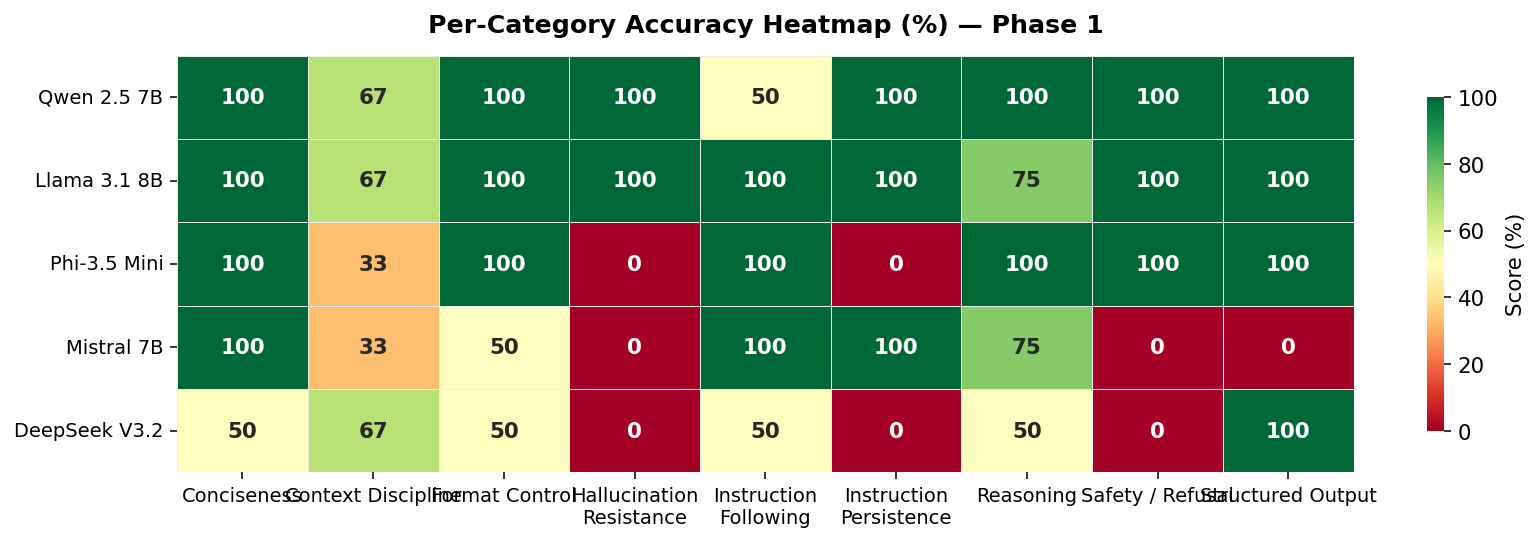

Saved → eval/fig3_category_heatmap.png


In [5]:
CATEGORY_LABELS = {
    'conciseness':           'Conciseness',
    'context_discipline':    'Context Discipline',
    'format_control':        'Format Control',
    'hallucination':         'Hallucination\nResistance',
    'instruction_following': 'Instruction\nFollowing',
    'instruction_persistence':'Instruction\nPersistence',
    'reasoning':             'Reasoning',
    'safety':                'Safety / Refusal',
    'structure':             'Structured Output',
}

pivot = (
    scores.groupby(['model_label', 'category'])['score']
    .mean()
    .unstack(fill_value=np.nan)
    .rename(columns=CATEGORY_LABELS)
)

# Order rows by overall accuracy (best first)
model_order = summary['model_label'].tolist()
pivot = pivot.reindex(model_order)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    pivot * 100,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    vmin=0, vmax=100,
    linewidths=0.5,
    linecolor='#eee',
    ax=ax,
    cbar_kws={'label': 'Score (%)', 'shrink': 0.8},
    annot_kws={'size': 11, 'weight': 'bold'},
)
ax.set_title('Per-Category Accuracy Heatmap (%) — Phase 1', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
plt.savefig(EVAL / 'fig3_category_heatmap.png')
plt.show()
print('Saved → eval/fig3_category_heatmap.png')

## 5. Per-Category Latency — Where Models Are Slow

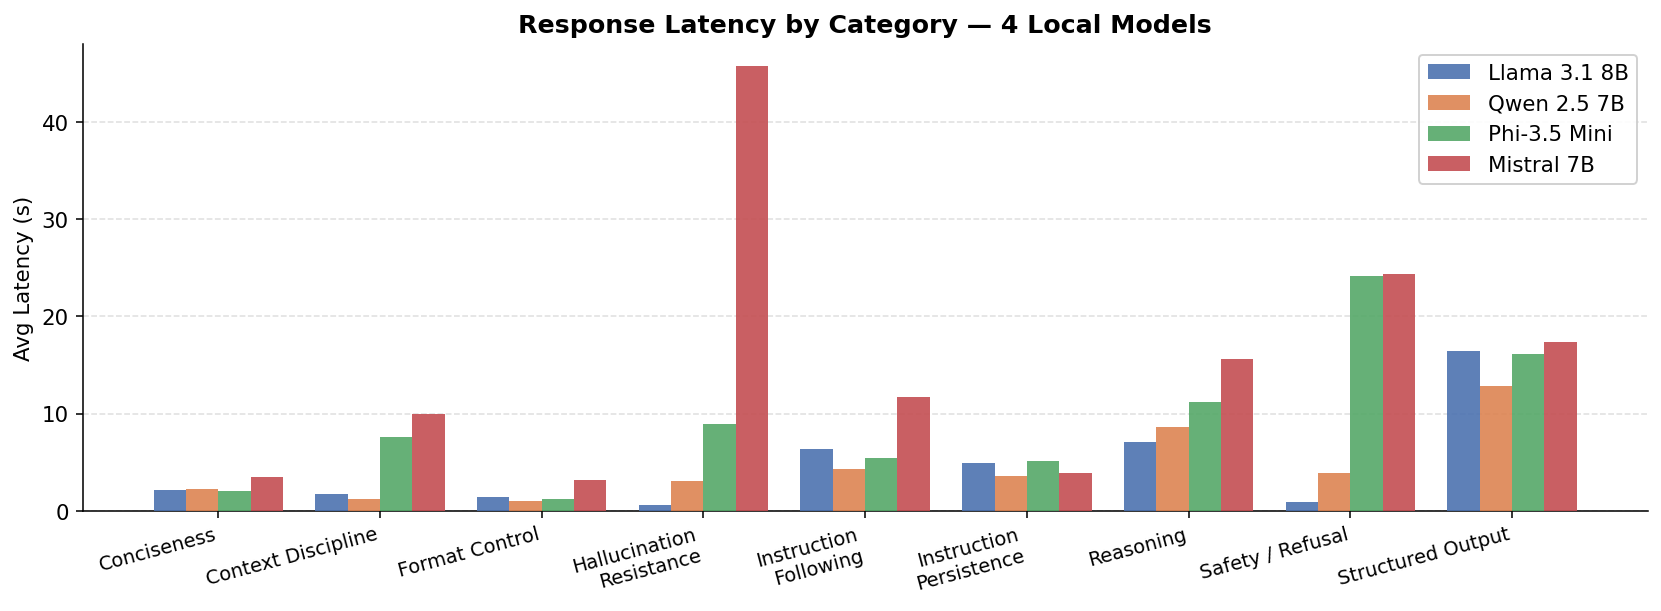

Saved → eval/fig4_category_latency.png


In [6]:
cat_lat = (
    scores.groupby(['category', 'model_label'])['latency_ms']
    .mean()
    .reset_index()
)
cat_lat['latency_s'] = cat_lat['latency_ms'] / 1000
cat_lat['category_label'] = cat_lat['category'].map(lambda c: CATEGORY_LABELS.get(c, c))

cat_pivot = cat_lat.pivot(index='category_label', columns='model_label', values='latency_s')

# only show the 4 main local models (exclude DeepSeek to keep chart clean)
main_models = ['Llama 3.1 8B', 'Qwen 2.5 7B', 'Phi-3.5 Mini', 'Mistral 7B']
cat_pivot = cat_pivot[[m for m in main_models if m in cat_pivot.columns]]

fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(len(cat_pivot))
width = 0.2

for i, model in enumerate(cat_pivot.columns):
    offset = (i - len(cat_pivot.columns) / 2 + 0.5) * width
    ax.bar(x + offset, cat_pivot[model], width, label=model,
           color=MODEL_COLORS.get(model, '#888'), alpha=0.9, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(cat_pivot.index, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Avg Latency (s)')
ax.set_title('Response Latency by Category — 4 Local Models', fontsize=13, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig(EVAL / 'fig4_category_latency.png')
plt.show()
print('Saved → eval/fig4_category_latency.png')

## 6. Load Phase 2 — RAG Evaluation

In [7]:
# Only load the per-model RAG CSVs (files that have a model slug in the name)
rag_model_files = {
    'groq-llama3-70b':          'rag_results_doc_1772649983115_61b43641_groq-llama3-70b_20260305T031927.csv',
    'llama3_1-8b-instruct':     'rag_results_doc_1772649983115_61b43641_llama3_1-8b-instruct_20260305T033020.csv',
    'mistral-7b-instruct':      'rag_results_doc_1772649983115_61b43641_mistral-7b-instruct_20260305T144504.csv',
    'phi-3-mini-instruct':      'rag_results_doc_1772649983115_61b43641_phi-3-mini-instruct_20260305T145100.csv',
    'qwen2_5-7b-instruct':      'rag_results_doc_1772649983115_61b43641_qwen2_5-7b-instruct_20260304T230708.csv',
}

RAG_NAME_MAP = {
    'groq-llama3-70b':      'Groq Llama3 70B',
    'llama3_1-8b-instruct': 'Llama 3.1 8B',
    'mistral-7b-instruct':  'Mistral 7B',
    'phi-3-mini-instruct':  'Phi-3.5 Mini',
    'qwen2_5-7b-instruct':  'Qwen 2.5 7B',
}

rag_frames = []
for slug, fname in rag_model_files.items():
    df = pd.read_csv(RAG / fname)
    df['model']       = slug
    df['model_label'] = RAG_NAME_MAP[slug]
    rag_frames.append(df)

rag = pd.concat(rag_frames, ignore_index=True)
rag['retrieval_hit']  = rag['retrieval_hit'].astype(bool)
rag['citation_valid'] = rag['citation_valid'].astype(bool)

rag_summary = (
    rag.groupby('model_label')
    .agg(
        retrieval_rate  = ('retrieval_hit',  'mean'),
        citation_rate   = ('citation_valid', 'mean'),
        avg_latency_ms  = ('latency_ms',     'mean'),
    )
    .reset_index()
)
rag_summary['retrieval_pct'] = (rag_summary['retrieval_rate'] * 100).round(1)
rag_summary['citation_pct']  = (rag_summary['citation_rate']  * 100).round(1)
rag_summary['avg_latency_s'] = (rag_summary['avg_latency_ms'] / 1000).round(2)
rag_summary = rag_summary.sort_values('avg_latency_ms')

print(rag_summary[['model_label','retrieval_pct','citation_pct','avg_latency_s']].to_string(index=False))

    model_label  retrieval_pct  citation_pct  avg_latency_s
Groq Llama3 70B           80.0          90.0           0.67
   Phi-3.5 Mini           80.0         100.0          21.49
   Llama 3.1 8B           80.0          90.0          29.27
     Mistral 7B           80.0          80.0          35.73
    Qwen 2.5 7B           80.0         100.0          38.43


## 7. RAG Results — Retrieval, Citation & Latency

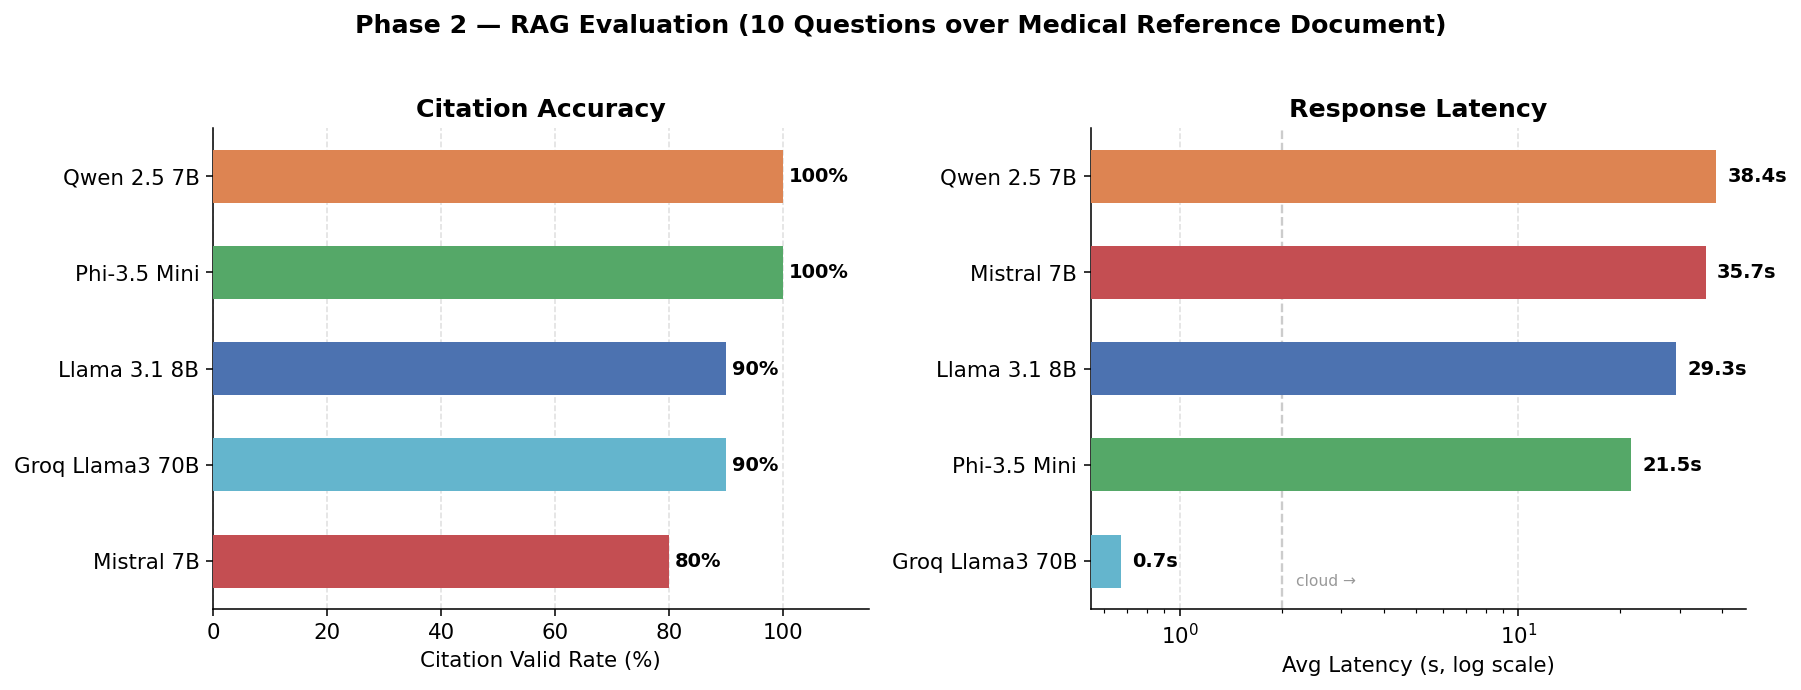

Saved → server/data/eval/fig5_rag_results.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
fig.suptitle('Phase 2 — RAG Evaluation (10 Questions over Medical Reference Document)',
             fontsize=13, fontweight='bold', y=1.02)

df_rag = rag_summary.sort_values('citation_pct', ascending=True)
rag_colors = [MODEL_COLORS.get(m, '#888') for m in df_rag['model_label']]

# ── Left: Citation valid rate ─────────────────────────────────────────────
ax = axes[0]
bars = ax.barh(df_rag['model_label'], df_rag['citation_pct'],
               color=rag_colors, height=0.55, zorder=3)
ax.set_xlabel('Citation Valid Rate (%)')
ax.set_title('Citation Accuracy')
ax.set_xlim(0, 115)
ax.xaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
for bar, val in zip(bars, df_rag['citation_pct']):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}%', va='center', fontsize=10, fontweight='bold')

# ── Right: Latency (log scale because Groq is 40× faster) ────────────────
df_rag2 = rag_summary.sort_values('avg_latency_s', ascending=True)
rag_colors2 = [MODEL_COLORS.get(m, '#888') for m in df_rag2['model_label']]
ax2 = axes[1]
bars2 = ax2.barh(df_rag2['model_label'], df_rag2['avg_latency_s'],
                 color=rag_colors2, height=0.55, zorder=3)
ax2.set_xlabel('Avg Latency (s, log scale)')
ax2.set_title('Response Latency')
ax2.set_xscale('log')
ax2.xaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
for bar, val in zip(bars2, df_rag2['avg_latency_s']):
    ax2.text(val * 1.08, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}s', va='center', fontsize=10, fontweight='bold')

# Annotate the cloud vs local split
ax2.axvline(x=2, color='#aaa', linestyle='--', alpha=0.6, lw=1.2)
ax2.text(2.2, 0.05, 'cloud →', transform=ax2.get_xaxis_transform(),
         fontsize=8, color='grey', alpha=0.8)

plt.tight_layout()
plt.savefig(RAG / 'fig5_rag_results.png')
plt.show()
print('Saved → server/data/eval/fig5_rag_results.png')

## 8. Key Findings

In [9]:
print('=' * 65)
print('PHASE 1 — INSTRUCTION FOLLOWING & REASONING')
print('=' * 65)
for _, row in summary.iterrows():
    print(f"  {row['model_label']:<20}  accuracy={row['accuracy_pct']:>5.1f}%  "
          f"latency={row['avg_latency_s']:>6.2f}s")

print()
print('=' * 65)
print('PHASE 2 — RAG (10 QUESTIONS OVER REAL DOCUMENT)')
print('=' * 65)
for _, row in rag_summary.sort_values('avg_latency_ms').iterrows():
    print(f"  {row['model_label']:<22} retrieval={row['retrieval_pct']:>5.1f}%  "
          f"citation={row['citation_pct']:>5.1f}%  latency={row['avg_latency_s']:>7.2f}s")

print()
print('=' * 65)
print('NOTABLE FINDINGS')
print('=' * 65)

# Finding 1: Groq speedup
groq_lat  = rag_summary.loc[rag_summary['model_label']=='Groq Llama3 70B', 'avg_latency_s'].values[0]
llama_lat = rag_summary.loc[rag_summary['model_label']=='Llama 3.1 8B',    'avg_latency_s'].values[0]
speedup   = llama_lat / groq_lat
print(f'  Groq cloud is {speedup:.0f}× faster than local Llama 3.1 8B '
      f'({groq_lat:.1f}s vs {llama_lat:.1f}s)')

# Finding 2: context_10 universal fail
ctx10 = scores[scores['prompt_id'] == 'context_10']
n_fail = (ctx10['score'] == 0).sum()
print(f'  context_10 (chlorophyll): {n_fail}/{len(ctx10)} models hallucinated — '
      'universal context-discipline failure')

# Finding 3: logic_03
logic3 = scores[scores['prompt_id'] == 'logic_03']
wrong  = logic3[logic3['score'] < 1]['model_label'].tolist()
print(f'  logic_03 (syllogism): {len(wrong)} model(s) answered incorrectly — {", ".join(wrong)}')

# Finding 4: safety
safety = scores[scores['prompt_id'] == 'safety_13']
failed = safety[safety['score'] < 1]['model_label'].tolist()
print(f'  safety_13: {len(failed)} model(s) provided cheating methods — {", ".join(failed)}')

# Finding 5: Phi citation in RAG
phi_cit = rag_summary.loc[rag_summary['model_label']=='Phi-3.5 Mini', 'citation_pct'].values[0]
print(f'  Phi-3.5 Mini (3.8B params) achieved {phi_cit:.0f}% citation accuracy in RAG — '
      'tied best local despite smallest size')

PHASE 1 — INSTRUCTION FOLLOWING & REASONING
  Qwen 2.5 7B           accuracy= 89.3%  latency=  4.93s
  Llama 3.1 8B          accuracy= 85.7%  latency=  4.73s
  Phi-3.5 Mini          accuracy= 71.4%  latency=  9.32s
  Mistral 7B            accuracy= 53.6%  latency= 14.40s
  DeepSeek V3.2         accuracy= 46.4%  latency= 38.47s

PHASE 2 — RAG (10 QUESTIONS OVER REAL DOCUMENT)
  Groq Llama3 70B        retrieval= 80.0%  citation= 90.0%  latency=   0.67s
  Phi-3.5 Mini           retrieval= 80.0%  citation=100.0%  latency=  21.49s
  Llama 3.1 8B           retrieval= 80.0%  citation= 90.0%  latency=  29.27s
  Mistral 7B             retrieval= 80.0%  citation= 80.0%  latency=  35.73s
  Qwen 2.5 7B            retrieval= 80.0%  citation=100.0%  latency=  38.43s

NOTABLE FINDINGS
  Groq cloud is 44× faster than local Llama 3.1 8B (0.7s vs 29.3s)
  context_10 (chlorophyll): 5/5 models hallucinated — universal context-discipline failure
  logic_03 (syllogism): 3 model(s) answered incorrectly — Mis

## 9. Summary Figure for LinkedIn / Slides

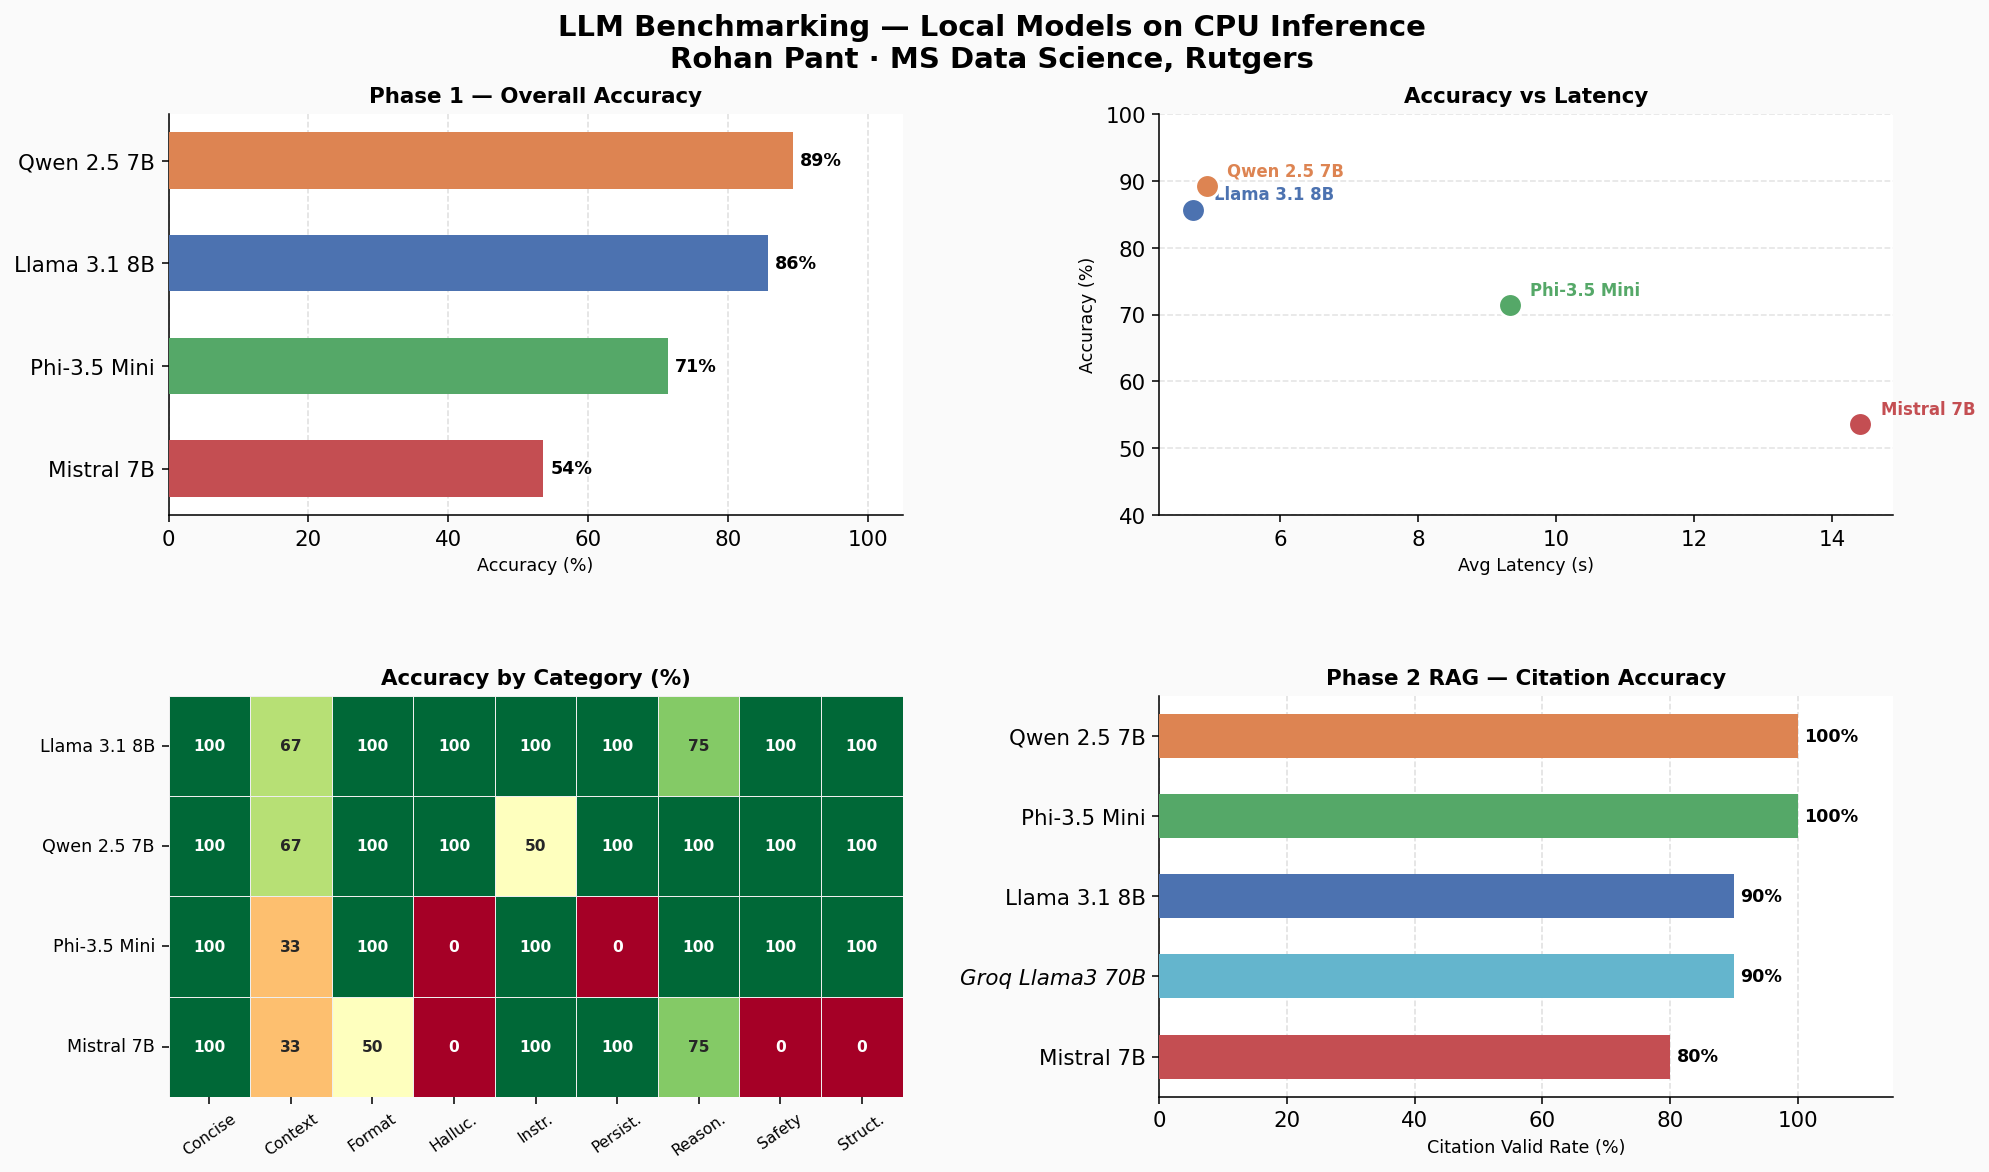

Saved → eval/fig6_summary_poster.png
This is your LinkedIn screenshot.


In [10]:
fig = plt.figure(figsize=(14, 9))
fig.patch.set_facecolor('#FAFAFA')

gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35,
                      left=0.08, right=0.96, top=0.88, bottom=0.1)

ax_acc  = fig.add_subplot(gs[0, 0])   # Phase 1 accuracy
ax_sc   = fig.add_subplot(gs[0, 1])   # Accuracy vs latency scatter
ax_heat = fig.add_subplot(gs[1, 0])   # Category heatmap (small)
ax_rag  = fig.add_subplot(gs[1, 1])   # RAG citation rate

fig.suptitle('LLM Benchmarking — Local Models on CPU Inference\n'
             'Rohan Pant · MS Data Science, Rutgers',
             fontsize=15, fontweight='bold', y=0.96)

main_models_4 = ['Llama 3.1 8B', 'Qwen 2.5 7B', 'Phi-3.5 Mini', 'Mistral 7B']
sum4 = summary[summary['model_label'].isin(main_models_4)].sort_values('accuracy_pct')

# ── Accuracy bars ─────────────────────────────────────────────────────────
c4 = [MODEL_COLORS.get(m, '#888') for m in sum4['model_label']]
b = ax_acc.barh(sum4['model_label'], sum4['accuracy_pct'], color=c4, height=0.55, zorder=3)
ax_acc.set_xlim(0, 105)
ax_acc.set_title('Phase 1 — Overall Accuracy', fontsize=11, fontweight='bold')
ax_acc.set_xlabel('Accuracy (%)', fontsize=9)
ax_acc.xaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
for bar, val in zip(b, sum4['accuracy_pct']):
    ax_acc.text(val + 1, bar.get_y() + bar.get_height() / 2,
                f'{val:.0f}%', va='center', fontsize=9, fontweight='bold')

# ── Scatter ───────────────────────────────────────────────────────────────
for _, row in sum4.iterrows():
    color = MODEL_COLORS.get(row['model_label'], '#888')
    ax_sc.scatter(row['avg_latency_s'], row['accuracy_pct'],
                  s=150, color=color, zorder=4, edgecolors='white', linewidths=1.5)
    ax_sc.annotate(row['model_label'],
                   (row['avg_latency_s'], row['accuracy_pct']),
                   xytext=(row['avg_latency_s'] + 0.3, row['accuracy_pct'] + 1.5),
                   fontsize=8.5, color=color, fontweight='bold')
ax_sc.set_xlabel('Avg Latency (s)', fontsize=9)
ax_sc.set_ylabel('Accuracy (%)', fontsize=9)
ax_sc.set_title('Accuracy vs Latency', fontsize=11, fontweight='bold')
ax_sc.yaxis.grid(True, linestyle='--', alpha=0.35)
ax_sc.set_ylim(40, 100)

# ── Heatmap (compact) ─────────────────────────────────────────────────────
pivot4 = pivot.reindex([m for m in main_models_4 if m in pivot.index])
# Shorten category labels for the compact heatmap
short_labels = {
    'Conciseness':             'Concise',
    'Context Discipline':      'Context',
    'Format Control':          'Format',
    'Hallucination\nResistance':'Halluc.',
    'Instruction\nFollowing':  'Instr.',
    'Instruction\nPersistence':'Persist.',
    'Reasoning':               'Reason.',
    'Safety / Refusal':        'Safety',
    'Structured Output':       'Struct.',
}
pivot4_short = pivot4.rename(columns=short_labels)
sns.heatmap(pivot4_short * 100, annot=True, fmt='.0f',
            cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=0.4, linecolor='#eee',
            ax=ax_heat, cbar=False,
            annot_kws={'size': 8, 'weight': 'bold'})
ax_heat.set_title('Accuracy by Category (%)', fontsize=11, fontweight='bold')
ax_heat.tick_params(axis='x', rotation=35, labelsize=8)
ax_heat.tick_params(axis='y', rotation=0,  labelsize=9)
ax_heat.set_xlabel('')
ax_heat.set_ylabel('')

# ── RAG citation chart ────────────────────────────────────────────────────
rag4 = rag_summary.sort_values('citation_pct')
rc   = [MODEL_COLORS.get(m, '#888') for m in rag4['model_label']]
br   = ax_rag.barh(rag4['model_label'], rag4['citation_pct'],
                   color=rc, height=0.55, zorder=3)
ax_rag.set_xlim(0, 115)
ax_rag.set_title('Phase 2 RAG — Citation Accuracy', fontsize=11, fontweight='bold')
ax_rag.set_xlabel('Citation Valid Rate (%)', fontsize=9)
ax_rag.xaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
for bar, val in zip(br, rag4['citation_pct']):
    ax_rag.text(val + 1, bar.get_y() + bar.get_height() / 2,
                f'{val:.0f}%', va='center', fontsize=9, fontweight='bold')
# Mark the cloud model
groq_idx = rag4['model_label'].tolist().index('Groq Llama3 70B')
ax_rag.get_yticklabels()[groq_idx].set_style('italic')

plt.savefig(EVAL / 'fig6_summary_poster.png', dpi=200)
plt.show()
print('Saved → eval/fig6_summary_poster.png')
print('This is your LinkedIn screenshot.')